# ***0. IMPORTING LIBRARIES AND UPLOAD DATASET***

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df=pd.read_csv('/content/drive/MyDrive/DataSets/laptop_price.csv', encoding='latin1')


In [ ]:
df.shape

(1303, 13)

In [ ]:
df.head(15)

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
5,6,Acer,Aspire 3,Notebook,15.6,1366x768,AMD A9-Series 9420 3GHz,4GB,500GB HDD,AMD Radeon R5,Windows 10,2.1kg,400.00
6,7,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.2GHz,16GB,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04kg,2139.97
7,8,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,1158.70
8,9,Asus,ZenBook UX430UN,Ultrabook,14.0,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,512GB SSD,Nvidia GeForce MX150,Windows 10,1.3kg,1495.00
9,10,Acer,Swift 3,Ultrabook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,1.6kg,770.00


from this data head we concluded that:-

*   column product is useless
*   column ScreenResolution need to change its dtype and remove GB
*   column Ram need to change its dtype and remove GB
*   column laptop_ID used to our df index
*   column Weight need to change its dtype and remove KG
*   column Memory need to be splited to two cols memory size and memory type






# ***1. PREPROCESSING***

## **1.1 DEALING WITH laptop_ID COLUMN**




In [ ]:
df=df.set_index('laptop_ID')
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,
1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.2 DEALING WITH Product COLUMN**


In [ ]:
df.drop(columns='Product',inplace=True)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,
1,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.3 DEALING WITH ScreenResolution COLUMN**


In [ ]:
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [ ]:
df['IPS'] = df['ScreenResolution'].apply(lambda x: 1 if 'IPS' in x else 0)
df['Resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')
df[['Resolution_Width','Resolution_Height']]=df['Resolution'].str.split('x',expand=True)
df['Resolution_Height']=df['Resolution_Height'].astype(int)
df['Resolution_Width']=df['Resolution_Width'].astype(int)
H=df['Resolution_Height']
W=df['Resolution_Width']
df['ScreenPixels']=df['Resolution_Height']*df['Resolution_Width']
df['TouchScreen'] = df['ScreenResolution'].apply(lambda x: 1 if 'Touch' in x else 0)
df.drop(columns=['ScreenResolution','Resolution','Resolution_Width','Resolution_Height'],axis=1,inplace=True)
df=df[['Company', 'TypeName', 'Inches','ScreenPixels', 'TouchScreen','IPS', 'Cpu', 'Ram','Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']]


df.head()

,Company,TypeName,Inches,ScreenPixels,TouchScreen,IPS,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,
1,Apple,Ultrabook,13.3,4096000,0,1,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,13.3,1296000,0,0,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,15.6,2073600,0,0,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,15.4,5184000,0,1,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,13.3,4096000,0,1,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.4 CREATING PPI COLUMN INSTEAD OF INCHES & SCREENPIXELS**

In [ ]:
df['PPI'] = np.sqrt(W**2 + H**2) / df['Inches']
df.head()

,Company,TypeName,Inches,ScreenPixels,TouchScreen,IPS,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,PPI
laptop_ID,,,,,,,,,,,,,,
1,Apple,Ultrabook,13.3,4096000,0,1,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,226.983005
2,Apple,Ultrabook,13.3,1296000,0,0,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,127.677940
3,HP,Notebook,15.6,2073600,0,0,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,141.211998
4,Apple,Ultrabook,15.4,5184000,0,1,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,220.534624
5,Apple,Ultrabook,13.3,4096000,0,1,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,226.983005


In [ ]:
df.drop(columns=['Inches','ScreenPixels'],inplace=True)
df=df[['Company', 'TypeName', 'PPI','TouchScreen','IPS', 'Cpu', 'Ram','Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']]
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,127.677940,0,0,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,141.211998,0,0,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,220.534624,0,1,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,226.983005,0,1,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.5 DEALING WITH Cpu COLUMN**


In [ ]:
# import re

# def extract_cpu_key(cpu):
#     # handle NaN
#     if pd.isna(cpu):
#         return 'unknown'

#     cpu = str(cpu).lower()

#
#     if 'i3' in cpu:
#         cpu_type = 'i3'
#     elif 'i5' in cpu:
#         cpu_type = 'i5'
#     elif 'i7' in cpu:
#         cpu_type = 'i7'
#     elif 'i9' in cpu:
#         cpu_type = 'i9'
#     elif 'ryzen 3' in cpu:
#         cpu_type = 'r3'
#     elif 'ryzen 5' in cpu:
#         cpu_type = 'r5'
#     elif 'ryzen 7' in cpu:
#         cpu_type = 'r7'
#     else:
#         cpu_type = 'other'

#
#     match = re.search(r'(\d{4})', cpu)
#     gen = match.group(1) if match else '0000'

#     return f"{cpu_type}-{gen}"

In [ ]:
# df['cpu_key'] = df['Cpu'].apply(extract_cpu_key)

In [ ]:
# df['Cpu_ClockSpeed'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz')
# df['Cpu_ClockSpeed'] = df['Cpu_ClockSpeed'].astype(float)
# df['Cpu_Brand'] = df['Cpu'].apply(lambda x: x.split()[0])
# df['Cpu_Clean'] = df['Cpu'].str.replace(r'^\S+\s+', '', regex=True) \
#                              .str.replace(r'\d+\.?\d*GHz', '', regex=True) \
#                              .str.strip()
# df=df[['Company', 'TypeName', 'Inches','ScreenPixels', 'TouchScreen', 'Cpu_ClockSpeed','Cpu_Brand', 'Ram','Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']]


# df.head()

In [ ]:
# df_cpu = pd.read_excel('cpu_ranking.xlsx')
# df_cpu['cpu_key'] = df_cpu['CPU Name'].apply(extract_cpu_key)


# df = df.merge(
#     df_cpu[['cpu_key', 'Performance']],
#     on='cpu_key',
#     how='left'
# )

# df.rename(columns={'Performance': 'Cpu_Performance'}, inplace=True)




# df[['Cpu', 'cpu_key', 'Cpu_Performance']].sample(10)

In [ ]:
import re
from difflib import get_close_matches

# =========================
# 1) READ FILES

cpu_perf = pd.read_excel("/content/drive/MyDrive/DataSets/cpu_ranking.xlsx")


cpu_perf = cpu_perf[["CPU Name", "Performance"]].dropna()

# =========================
# 2) CLEANING
# =========================
def normalize_cpu_name(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()
    text = re.sub(r"\b\d+(\.\d+)?\s*ghz\b", "", text)

    text = text.replace("intel", " ")
    text = text.replace("amd", " ")

    text = re.sub(r"[^a-z0-9\-\+\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def extract_model(text):
    if not text:
        return None

    patterns = [
        r"\bi[3579]-\d{4,5}[a-z]{0,2}\b",
        r"\b\d{4,5}[a-z]{0,2}\b",
        r"\bn\d{4}\b",
        r"\bryzen\s+[3579]\s+\d{4}[a-z]{0,2}\b",
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)

    return None

# =========================
# 3) PREP REFERENCE
# =========================
cpu_perf["norm_cpu_name"] = cpu_perf["CPU Name"].apply(normalize_cpu_name)
cpu_perf["model_code"] = cpu_perf["norm_cpu_name"].apply(extract_model)

exact_map = dict(zip(cpu_perf["norm_cpu_name"], cpu_perf["Performance"]))

model_lookup = (
    cpu_perf.dropna(subset=["model_code"])
    .drop_duplicates(subset=["model_code"])
    .set_index("model_code")[["CPU Name", "Performance"]]
    .to_dict("index")
)

exact_lookup = (
    cpu_perf.drop_duplicates(subset=["norm_cpu_name"])
    .set_index("norm_cpu_name")[["CPU Name", "Performance"]]
    .to_dict("index")
)

all_norm_names = cpu_perf["norm_cpu_name"].tolist()

# =========================
# 4) MATCH WITH DETAILS
# =========================
def get_perf_with_details(cpu_value):
    norm = normalize_cpu_name(cpu_value)

    if not norm:
        return pd.Series([None, None, None, "no match"])

    # exact
    if norm in exact_lookup:
        return pd.Series([
            norm,
            exact_lookup[norm]["CPU Name"],
            exact_lookup[norm]["Performance"],
            "exact"
        ])

    # model
    code = extract_model(norm)
    if code and code in model_lookup:
        return pd.Series([
            norm,
            model_lookup[code]["CPU Name"],
            model_lookup[code]["Performance"],
            "model"
        ])

    # fuzzy
    match = get_close_matches(norm, all_norm_names, n=1, cutoff=0.75)
    if match:
        matched_norm = match[0]
        return pd.Series([
            norm,
            exact_lookup[matched_norm]["CPU Name"],
            exact_lookup[matched_norm]["Performance"],
            "fuzzy"
        ])

    return pd.Series([norm, None, None, "no match"])

# =========================
# 5) APPLY
# =========================
df[["normalized_cpu", "matched_cpu_name", "cpu_performance", "match_type"]] = (
    df["Cpu"].apply(get_perf_with_details)
)

# =========================
# 6) DISPLAY MATCHING
# =========================
matching_view = df[["Cpu", "normalized_cpu", "matched_cpu_name", "cpu_performance", "match_type"]]

matching_view.head(50)

,Cpu,normalized_cpu,matched_cpu_name,cpu_performance,match_type
laptop_ID,,,,,
1,Intel Core i5 2.3GHz,core i5,Core i7-975,2.02,fuzzy
2,Intel Core i5 1.8GHz,core i5,Core i7-975,2.02,fuzzy
3,Intel Core i5 7200U 2.5GHz,core i5 7200u,Core i5-7200U,1.93,fuzzy
4,Intel Core i7 2.7GHz,core i7,Core i7-980,3.95,fuzzy
5,Intel Core i5 3.1GHz,core i5,Core i7-975,2.02,fuzzy
6,AMD A9-Series 9420 3GHz,a9-series 9420,A9-9420,0.87,model
7,Intel Core i7 2.2GHz,core i7,Core i7-980,3.95,fuzzy
8,Intel Core i5 1.8GHz,core i5,Core i7-975,2.02,fuzzy
9,Intel Core i7 8550U 1.8GHz,core i7 8550u,Core i7-8550U,3.50,fuzzy


In [ ]:
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,normalized_cpu,matched_cpu_name,cpu_performance,match_type
laptop_ID,,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,core i5,Core i7-975,2.02,fuzzy
2,Apple,Ultrabook,127.677940,0,0,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,core i5,Core i7-975,2.02,fuzzy
3,HP,Notebook,141.211998,0,0,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,core i5 7200u,Core i5-7200U,1.93,fuzzy
4,Apple,Ultrabook,220.534624,0,1,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,core i7,Core i7-980,3.95,fuzzy
5,Apple,Ultrabook,226.983005,0,1,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,core i5,Core i7-975,2.02,fuzzy


In [ ]:
df['cpu_performance'].unique()

array([2.02, 1.93, 3.95, 0.87, 3.5 , 3.52, 1.3 ,  nan, 2.08, 1.56, 0.51,
       2.9 , 3.54, 0.48, 0.7 , 0.75, 0.64, 2.32, 3.93, 8.43, 1.23, 0.65,
       0.37, 1.89, 2.18, 1.71, 1.34, 3.63, 4.15, 1.48, 4.23, 4.24, 1.87,
       1.44, 9.68, 0.55, 4.09, 1.32, 2.11, 1.57, 0.79, 1.5 , 1.13, 2.86,
       3.86, 7.  , 1.45, 3.12, 2.3 , 1.4 , 1.46, 3.73, 4.01, 4.63, 0.68,
       1.83, 0.34, 1.24, 2.67, 1.54, 4.28, 1.82, 1.39, 1.21, 4.17, 1.91,
       1.62, 0.84, 0.71, 1.31, 0.88])

In [ ]:
df['cpu_performance'].isnull().sum()

np.int64(9)

In [ ]:
df.drop(columns=['Cpu','normalized_cpu','matched_cpu_name','match_type'],axis=1,inplace=True)
df=df[['Company', 'TypeName', 'PPI','TouchScreen','IPS', 'cpu_performance', 'Ram','Memory', 'Gpu', 'OpSys', 'Weight', 'Price_euros']]
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,141.211998,0,0,1.93,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.6 DEALING WITH Ram COLUMN**


In [ ]:
df['Ram']=df['Ram'].str.replace('GB','').astype(int)
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


## **1.7 DEALING WITH Memory COLUMN**


In [ ]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [ ]:
df['Memory'] = df['Memory'].astype(str).replace('\.0','',regex = True)
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid',
       '512GB SSD +  1TB Hybrid', '256GB SSD +  1TB Hybrid'], dtype=object)

In [ ]:
df[['Memory_HDD','Memory_SSD','Memory_Flash Storage','Memory_Hybrid']]=0
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory,Gpu,OpSys,Weight,Price_euros,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid
laptop_ID,,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,0,0,0,0
2,Apple,Ultrabook,127.677940,0,0,2.02,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94,0,0,0,0
3,HP,Notebook,141.211998,0,0,1.93,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00,0,0,0,0
4,Apple,Ultrabook,220.534624,0,1,3.95,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45,0,0,0,0
5,Apple,Ultrabook,226.983005,0,1,2.02,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,0,0,0,0


In [ ]:
for i,col in enumerate(df['Memory']):
  if '+' in col:
    for n,z in enumerate(col.split()):
      if 'GB' in z:
        x=int(z.replace('GB',''))
        if col.split()[n+1] == 'SSD':
          df.loc[df.index[i], 'Memory_SSD'] = df.loc[df.index[i],'Memory_SSD']+x
        elif col.split()[n+1] == 'HDD':
          df.loc[df.index[i], 'Memory_HDD'] = df.loc[df.index[i],'Memory_HDD']+x
        elif col.split()[n+1] == 'Hybrid':
          df.loc[df.index[i], 'Memory_Hybrid'] = df.loc[df.index[i],'Memory_Hybrid']+x
        elif col.split()[n+1] == 'Flash':
          df.loc[df.index[i], 'Memory_Flash Storage'] = df.loc[df.index[i],'Memory_Flash Storage']+x
      elif 'TB' in z:
        x=int(z.replace('TB','000'))
        if col.split()[n+1] == 'SSD':
          df.loc[df.index[i], 'Memory_SSD'] = df.loc[df.index[i],'Memory_SSD']+x
        elif col.split()[n+1] == 'HDD':
          df.loc[df.index[i], 'Memory_HDD'] = df.loc[df.index[i],'Memory_HDD']+x
        elif col.split()[n+1] == 'Hybrid':
          df.loc[df.index[i], 'Memory_Hybrid'] = df.loc[df.index[i],'Memory_Hybrid']+x
        elif col.split()[n+1] == 'Flash':
          df.loc[df.index[i], 'Memory_Flash Storage'] = df.loc[df.index[i],'Memory_Flash Storage']+x


  elif 'SSD' in col:
    for n,z in enumerate(col.split()):
      if 'GB' in z:
        x=int(z.replace('GB',''))
        df.loc[df.index[i], 'Memory_SSD'] = df.loc[df.index[i],'Memory_SSD']+x
      elif 'TB' in z:
        x=int(z.replace('TB','000'))
        df.loc[df.index[i], 'Memory_SSD'] = df.loc[df.index[i],'Memory_SSD']+x


  elif 'HDD' in col:
    for z in col.split():
      if 'GB' in z:
        x=int(z.replace('GB',''))
        df.loc[df.index[i], 'Memory_HDD'] = df.loc[df.index[i],'Memory_HDD']+x
      elif 'TB' in z:
        x=int(z.replace('TB','000'))
        df.loc[df.index[i], 'Memory_HDD'] = df.loc[df.index[i],'Memory_HDD']+x



  elif 'Flash' in col:
    for z in col.split():
      if 'GB' in z:
        x=int(z.replace('GB',''))
        df.loc[df.index[i], 'Memory_Flash Storage'] = df.loc[df.index[i],'Memory_Flash Storage']+x
      elif 'TB' in z:
        x=int(z.replace('TB','000'))
        df.loc[df.index[i], 'Memory_Flash Storage'] = df.loc[df.index[i],'Memory_Flash Storage']+x


  elif 'Hybrid' in col:
    for z in col.split():
      if 'GB' in z:
        x=int(z.replace('GB',''))
        df.loc[df.index[i], 'Memory_Hybrid'] = df.loc[df.index[i],'Memory_Hybrid']+x
      elif 'TB' in z:
        x=int(z.replace('TB','000'))
        df.loc[df.index[i], 'Memory_Hybrid'] = df.loc[df.index[i],'Memory_Hybrid']+x

In [ ]:
df.drop(columns='Memory',axis=1,inplace=True)
df=df[['Company', 'TypeName', 'PPI','TouchScreen','IPS', 'cpu_performance', 'Ram','Memory_HDD','Memory_SSD','Memory_Flash Storage','Memory_Hybrid', 'Gpu', 'OpSys', 'Weight', 'Price_euros']]

df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,Gpu,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,Intel HD Graphics 6000,macOS,1.34kg,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,Intel HD Graphics 620,No OS,1.86kg,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,AMD Radeon Pro 455,macOS,1.83kg,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
# df[['Storage_Size', 'Storage_Type']] = df['Memory'].str.split(' ', n=1, expand=True)
# df['Storage_Size'] = df['Storage_Size'].str.replace('GB', '')
# df['Storage_Size'] = df['Storage_Size'].str.replace('TB', '000')
# df['Storage_Size'] = df['Storage_Size'].str.replace('1.0000', '1000')
# df['Storage_Type'] = df['Storage_Type'].str.replace('1.0', '1')
# df['Storage_Size'] = df['Storage_Size'].astype(int)

# for i,col in enumerate(df['Storage_Type']):
#   if '+' in col:
#     for z in col.split():
#       if 'TB' in z:
#         x=int(z.replace('TB',''))*1000
#         df.loc[df.index[i], 'Storage_Size'] = df.loc[df.index[i],'Storage_Size']+x
#         df.loc[df.index[i], 'Storage_Type'] = 'Hybrid'
#       elif 'GB' in z:
#         x=int(z.replace('GB',''))
#         df.loc[df.index[i], 'Storage_Size'] = df.loc[df.index[i], 'Storage_Size']+x
#         df.loc[df.index[i], 'Storage_Type'] = 'Hybrid'




## **1.8 DEALING WITH Gpu COLUMN**


In [ ]:
import pandas as pd
import re
from difflib import get_close_matches

gpu_perf = pd.read_excel("/content/drive/MyDrive/DataSets/all_gpu_ranking_1566.xlsx")
gpu_perf = gpu_perf[["GPU Name", "Performance"]].dropna()

def normalize_gpu_name(text):
    if pd.isna(text):
        return ""

    text = str(text).lower().strip()

    # remove vram
    text = re.sub(r"\b\d+\s*gb\b", "", text)

    # unify separators
    text = text.replace("/", " ")
    text = text.replace("-", " ")

    # normalize common forms
    replacements = {
        "intel hd graphics": "hd graphics",
        "intel uhd graphics": "uhd graphics",
        "intel iris plus graphics": "iris plus graphics",
        "intel iris xe graphics": "iris xe graphics",
        "intel iris graphics": "iris graphics",
        "intel graphics": "hd graphics",

        "nvidia geforce": "geforce",
        "amd radeon": "radeon",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^a-z0-9\+\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def extract_gpu_model(text):
    if not text:
        return None

    patterns = [
        r"\bhd graphics p?\d{3,4}\b",
        r"\buhd graphics \d{3,4}\b",
        r"\biris plus graphics \d{3,4}\b",
        r"\biris graphics \d{3,4}\b",
        r"\biris xe graphics\b",
        r"\biris xe graphics g7 96eus\b",
        r"\btiger lake u xe graphics g7\b",

        r"\bgeforce rtx \d{3,4}\s*ti\b",
        r"\bgeforce rtx \d{3,4}\b",
        r"\bgeforce gtx \d{3,4}\s*ti\b",
        r"\bgeforce gtx \d{3,4}\b",
        r"\bgeforce mx\s*\d{2,4}\b",
        r"\bquadro [a-z]?\d{3,4}\b",

        r"\bradeon rx \d{3,4}\s*xt\b",
        r"\bradeon rx \d{3,4}\b",
        r"\bradeon r\d\s*m?\d{3,4}\b",
        r"\bradeon pro \d{3,4}\b",
        r"\bvega \d{1,2}\b",
    ]

    for p in patterns:
        m = re.search(p, text)
        if m:
            return m.group(0)

    return None


gpu_perf["norm_gpu_name"] = gpu_perf["GPU Name"].apply(normalize_gpu_name)
gpu_perf["gpu_model_code"] = gpu_perf["norm_gpu_name"].apply(extract_gpu_model)

exact_lookup = (
    gpu_perf.drop_duplicates(subset=["norm_gpu_name"])
    .set_index("norm_gpu_name")[["GPU Name", "Performance"]]
    .to_dict("index")
)

model_lookup = (
    gpu_perf.dropna(subset=["gpu_model_code"])
    .drop_duplicates(subset=["gpu_model_code"])
    .set_index("gpu_model_code")[["GPU Name", "Performance"]]
    .to_dict("index")
)

all_norm_gpu_names = gpu_perf["norm_gpu_name"].tolist()

def get_gpu_perf_with_details(gpu_value):
    norm = normalize_gpu_name(gpu_value)

    if not norm:
        return pd.Series([None, None, None, "no match"])

    # 1) exact
    if norm in exact_lookup:
        return pd.Series([
            norm,
            exact_lookup[norm]["GPU Name"],
            exact_lookup[norm]["Performance"],
            "exact"
        ])

    # 2) model
    code = extract_gpu_model(norm)
    if code and code in model_lookup:
        return pd.Series([
            norm,
            model_lookup[code]["GPU Name"],
            model_lookup[code]["Performance"],
            "model"
        ])

    # 3) fuzzy
    match = get_close_matches(norm, all_norm_gpu_names, n=1, cutoff=0.65)
    if match:
        matched_norm = match[0]
        return pd.Series([
            norm,
            exact_lookup[matched_norm]["GPU Name"],
            exact_lookup[matched_norm]["Performance"],
            "fuzzy"
        ])

    return pd.Series([norm, None, None, "no match"])

df[["normalized_gpu", "matched_gpu_name", "gpu_performance", "gpu_match_type"]] = (df["Gpu"].apply(get_gpu_perf_with_details))

In [ ]:
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,Gpu,OpSys,Weight,Price_euros,normalized_gpu,matched_gpu_name,gpu_performance,gpu_match_type
laptop_ID,,,,,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69,iris plus graphics 640,Iris Plus Graphics 640,3.56,exact
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,Intel HD Graphics 6000,macOS,1.34kg,898.94,hd graphics 6000,HD Graphics 6000,2.03,exact
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,Intel HD Graphics 620,No OS,1.86kg,575.00,hd graphics 620,HD Graphics 620,2.24,exact
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,AMD Radeon Pro 455,macOS,1.83kg,2537.45,radeon pro 455,Radeon Pro 455,7.44,exact
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60,iris plus graphics 650,Iris Plus Graphics 650,4.20,exact


In [ ]:
df[df["Gpu"].str.contains("Intel", case=False, na=False)][
    ["Gpu", "normalized_gpu", "matched_gpu_name", "gpu_performance", "gpu_match_type"]
].drop_duplicates().head(50)

,Gpu,normalized_gpu,matched_gpu_name,gpu_performance,gpu_match_type
laptop_ID,,,,,
1,Intel Iris Plus Graphics 640,iris plus graphics 640,Iris Plus Graphics 640,3.56,exact
2,Intel HD Graphics 6000,hd graphics 6000,HD Graphics 6000,2.03,exact
3,Intel HD Graphics 620,hd graphics 620,HD Graphics 620,2.24,exact
5,Intel Iris Plus Graphics 650,iris plus graphics 650,Iris Plus Graphics 650,4.20,exact
7,Intel Iris Pro Graphics,intel iris pro graphics,Iris Pro Graphics 580,4.40,fuzzy
10,Intel UHD Graphics 620,uhd graphics 620,UHD Graphics 620,2.46,exact
12,Intel HD Graphics 520,hd graphics 520,HD Graphics 520,1.99,exact
15,Intel HD Graphics 615,hd graphics 615,HD Graphics 615,1.72,exact
21,Intel HD Graphics 400,hd graphics 400,HD Graphics 400,1.04,exact


In [ ]:
df['gpu_performance'].isnull().sum()

np.int64(3)

In [ ]:
df[df['gpu_performance'].isnull()].head(3)

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,Gpu,OpSys,Weight,Price_euros,normalized_gpu,matched_gpu_name,gpu_performance,gpu_match_type
laptop_ID,,,,,,,,,,,,,,,,,,,
181,MSI,Gaming,119.723216,0,0,4.15,32,1000,512,0,0,Nvidia GTX 980 SLI,Windows 10,4.4kg,2799.0,nvidia gtx 980 sli,None,NaN,no match
182,Lenovo,Notebook,141.211998,0,0,1.93,8,1000,128,0,0,AMD R17M-M1-70,Windows 10,1.90kg,813.0,amd r17m m1 70,None,NaN,no match
1209,Samsung,2 in 1 Convertible,234.507400,1,1,NaN,4,0,0,32,0,ARM Mali T860 MP4,Chrome OS,1.15kg,659.0,arm mali t860 mp4,None,NaN,no match


In [ ]:
# df_gpu=pd.read_excel('all_gpu_ranking_1566.xlsx')
# from rapidfuzz import process

# gpu_list = df_gpu['GPU Name'].astype(str).tolist()

# def match_gpu(name):
#     match = process.extractOne(name, gpu_list)
#     if match[1] > 80:  # threshold
#         return df_gpu[df_gpu['GPU Name'] == match[0]]['Performance'].values[0]
#     return np.nan

# df['Gpu_Performance'] = df['Gpu'].apply(match_gpu)

# df['Gpu_Performance'].unique()

In [ ]:
df.drop('Gpu', axis=1, inplace=True)
df=df[['Company', 'TypeName', 'PPI','TouchScreen','IPS', 'cpu_performance', 'Ram','Memory_HDD','Memory_SSD','Memory_Flash Storage','Memory_Hybrid', 'gpu_performance', 'OpSys', 'Weight', 'Price_euros']]

df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,gpu_performance,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,3.56,macOS,1.37kg,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,2.03,macOS,1.34kg,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,2.24,No OS,1.86kg,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,7.44,macOS,1.83kg,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,4.20,macOS,1.37kg,1803.60


## **1.9 DEALING WITH Weight COLUMN**


In [ ]:
df['Weight']=df['Weight'].str.replace('kg','').astype(float)
df.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,gpu_performance,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,3.56,macOS,1.37,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,2.03,macOS,1.34,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,2.24,No OS,1.86,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,7.44,macOS,1.83,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,4.20,macOS,1.37,1803.60


## ***1.10 DEALING WITH OpSys COLUMN***

In [ ]:
print(df['Company'].unique())
print(df['TypeName'].unique())
print(df['OpSys'].unique())

['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']
['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']
['macOS' 'No OS' 'Windows 10' 'Mac OS X' 'Linux' 'Android' 'Windows 10 S'
 'Chrome OS' 'Windows 7']


In [ ]:
df['OpSys'] = df['OpSys'].apply(
    lambda val: 'Windows' if 'Windows' in val
    else 'Mac' if ('Mac' in val or 'macOS' in val)
    else 'Other'
)
print(df['OpSys'].unique())

['Mac' 'Other' 'Windows']


In [ ]:
df.head()


,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,gpu_performance,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,3.56,Mac,1.37,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,2.03,Mac,1.34,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,2.24,Other,1.86,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,7.44,Mac,1.83,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,4.20,Mac,1.37,1803.60


# ***2. EDA***

In [ ]:
print(df.shape)
df.head()

(1303, 15)


,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,gpu_performance,OpSys,Weight,Price_euros
laptop_ID,,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,3.56,Mac,1.37,1339.69
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,2.03,Mac,1.34,898.94
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,2.24,Other,1.86,575.00
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,7.44,Mac,1.83,2537.45
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,4.20,Mac,1.37,1803.60


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 1 to 1320
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1303 non-null   object 
 1   TypeName              1303 non-null   object 
 2   PPI                   1303 non-null   float64
 3   TouchScreen           1303 non-null   int64  
 4   IPS                   1303 non-null   int64  
 5   cpu_performance       1294 non-null   float64
 6   Ram                   1303 non-null   int64  
 7   Memory_HDD            1303 non-null   int64  
 8   Memory_SSD            1303 non-null   int64  
 9   Memory_Flash Storage  1303 non-null   int64  
 10  Memory_Hybrid         1303 non-null   int64  
 11  gpu_performance       1300 non-null   float64
 12  OpSys                 1303 non-null   object 
 13  Weight                1303 non-null   float64
 14  Price_euros           1303 non-null   float64
dtypes: float64(5), int64(7), o

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PPI,1303.0,146.635987,43.121345,90.583402,127.335675,141.211998,157.350512,352.465147
TouchScreen,1303.0,0.147352,0.354593,0.000000,0.000000,0.000000,0.000000,1.000000
IPS,1303.0,0.280123,0.449231,0.000000,0.000000,0.000000,1.000000,1.000000
cpu_performance,1294.0,2.404026,1.414505,0.340000,1.560000,1.930000,3.520000,9.680000
Ram,1303.0,8.382195,5.084665,2.000000,4.000000,8.000000,8.000000,64.000000
Memory_HDD,1303.0,413.783576,515.818779,0.000000,0.000000,0.000000,1000.000000,2000.000000
Memory_SSD,1303.0,183.732924,186.966903,0.000000,0.000000,256.000000,256.000000,1024.000000
Memory_Flash Storage,1303.0,4.555641,30.274090,0.000000,0.000000,0.000000,0.000000,512.000000
Memory_Hybrid,1303.0,8.831926,92.567185,0.000000,0.000000,0.000000,0.000000,1000.000000
gpu_performance,1300.0,5.392500,7.363275,0.040000,1.990000,2.240000,3.610000,37.330000


In [ ]:
df.isnull().sum()

,0
Company,0
TypeName,0
PPI,0
TouchScreen,0
IPS,0
cpu_performance,9
Ram,0
Memory_HDD,0
Memory_SSD,0
Memory_Flash Storage,0


from this data exploring we concluded that:-

*   there is null values in cpu_performance & gpu_performance
*   categorical data need to be encoded



## **2.1 SPLITTING FEATURES & TARGET**

In [ ]:
df.columns

Index(['Company', 'TypeName', 'PPI', 'TouchScreen', 'IPS', 'cpu_performance',
       'Ram', 'Memory_HDD', 'Memory_SSD', 'Memory_Flash Storage',
       'Memory_Hybrid', 'gpu_performance', 'OpSys', 'Weight', 'Price_euros'],
      dtype='object')

In [ ]:
x=df.drop('Price_euros',axis=1)
y=df[['Price_euros']]

In [ ]:
y = df['Price_euros']
x = df.drop('Price_euros', axis=1)
numerical_feat =  x.select_dtypes(exclude=['object'])

categorical_feat = x.select_dtypes(exclude=['number'])

print(categorical_feat.columns)
print(numerical_feat.columns)


Index(['Company', 'TypeName', 'OpSys'], dtype='object')
Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')


In [ ]:
df['Weight'].unique()

array([1.37 , 1.34 , 1.86 , 1.83 , 2.1  , 2.04 , 1.3  , 1.6  , 2.2  ,
       0.92 , 1.22 , 0.98 , 2.5  , 1.62 , 1.91 , 2.3  , 1.35 , 1.88 ,
       1.89 , 1.65 , 2.71 , 1.2  , 1.44 , 2.8  , 2.   , 2.65 , 2.77 ,
       3.2  , 0.69 , 1.49 , 2.4  , 2.13 , 2.43 , 1.7  , 1.4  , 1.8  ,
       1.9  , 3.   , 1.252, 2.7  , 2.02 , 1.63 , 1.96 , 1.21 , 2.45 ,
       1.25 , 1.5  , 2.62 , 1.38 , 1.58 , 1.85 , 1.23 , 1.26 , 2.16 ,
       2.36 , 2.05 , 1.32 , 1.75 , 0.97 , 2.9  , 2.56 , 1.48 , 1.74 ,
       1.1  , 1.56 , 2.03 , 1.05 , 4.4  , 1.29 , 1.95 , 2.06 , 1.12 ,
       1.42 , 3.49 , 3.35 , 2.23 , 4.42 , 2.69 , 2.37 , 4.7  , 3.6  ,
       2.08 , 4.3  , 1.68 , 1.41 , 4.14 , 2.18 , 2.24 , 2.67 , 2.14 ,
       1.36 , 2.25 , 2.15 , 2.19 , 2.54 , 3.42 , 1.28 , 2.33 , 1.45 ,
       2.79 , 1.84 , 2.6  , 2.26 , 3.25 , 1.59 , 1.13 , 1.78 , 1.15 ,
       1.27 , 1.43 , 2.31 , 1.16 , 1.64 , 2.17 , 1.47 , 3.78 , 1.79 ,
       0.91 , 1.99 , 4.33 , 1.93 , 1.87 , 2.63 , 3.4  , 3.14 , 1.94 ,
       1.24 , 4.6  ,

In [ ]:
cont_numerical_feat=x[['PPI','cpu_performance','gpu_performance','Weight']]
disc_numerical_feat=x[['IPS', 'TouchScreen','Ram','Memory_HDD','Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid']]

## **2.2 VISUALIZATION FOR NUMERICAL FEATURES**

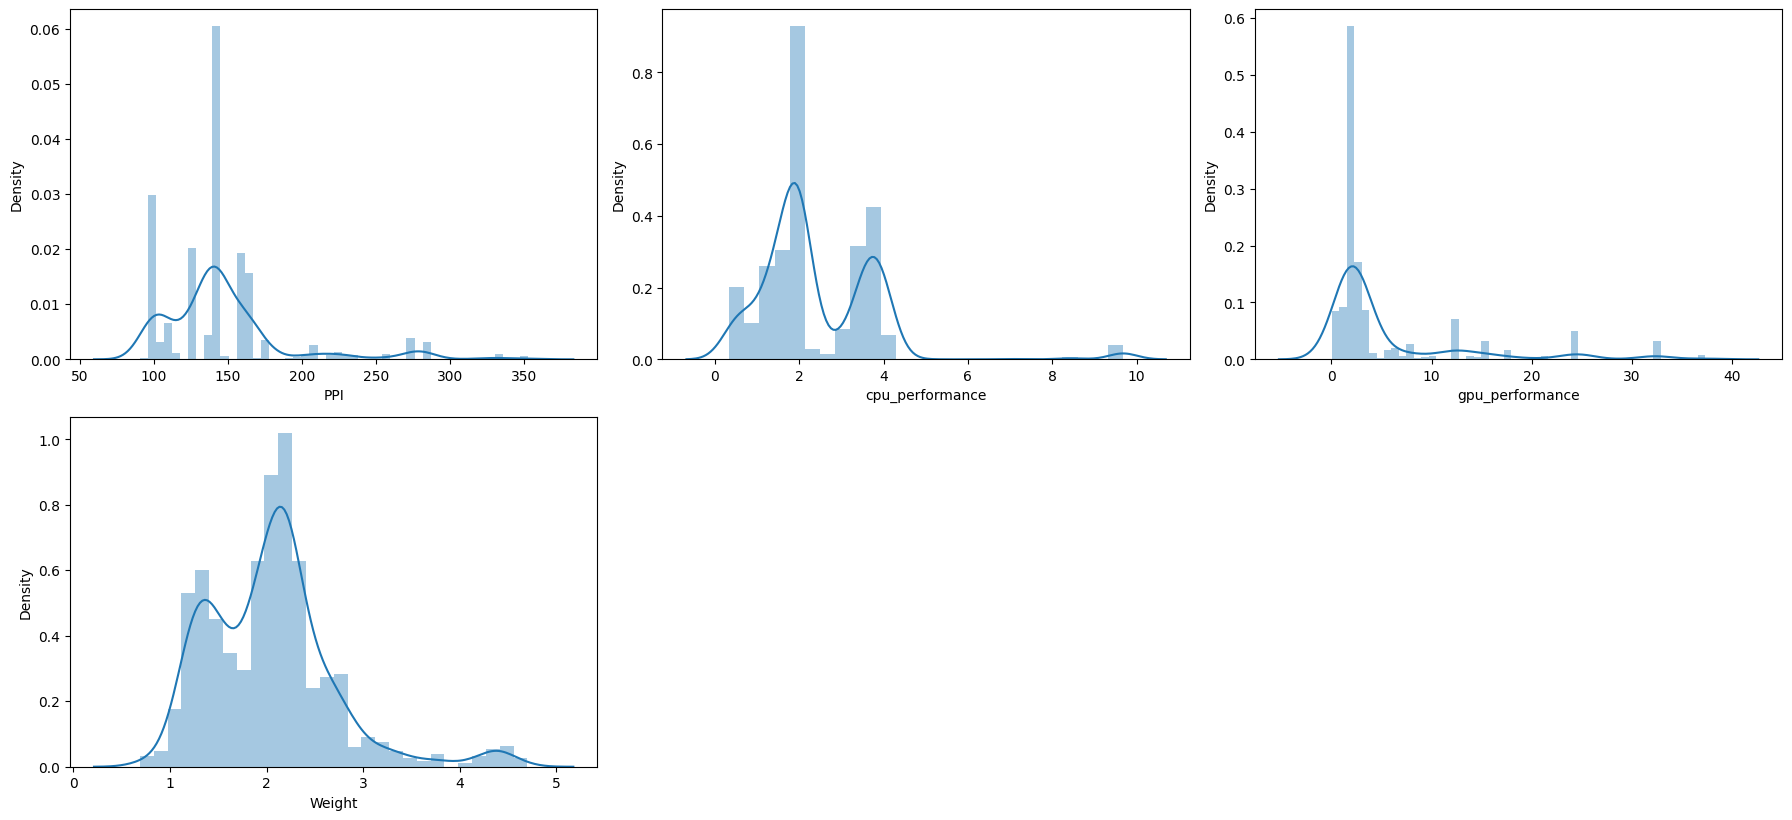

In [ ]:
fig = plt.figure(figsize=(18,16))
for index,col in enumerate(cont_numerical_feat):
    plt.subplot(4,3,index+1)
    sns.distplot(cont_numerical_feat.loc[:,col].dropna())
fig.tight_layout(pad=1.0)

from this distribution plt we concluded that:-

*   there is right skewed in weight values



## **2.3 VISUALIZATION FOR CONTINUOUS NUMERICAL FEATURES**

column PPI has outliers percentage = 8.902532617037606 %
identified outliers [226.98300468106115, 220.53462386625827, 226.98300468106115, 220.53462386625827, 220.53462386625827, 226.41554716935852, 226.98300468106115, 220.53462386625827, 276.053530085501, 226.98300468106115, 224.17380907857276, 226.41554716935852, 276.053530085501, 352.4651472131677, 331.2642361026012, 316.96506044349616, 282.42399616439724, 209.8006828649808, 254.67134914246222, 282.42399616439724, 282.42399616439724, 331.2642361026012, 226.98300468106115, 226.98300468106115, 209.8006828649808, 331.2642361026012, 331.2642361026012, 282.42399616439724, 316.96506044349616, 282.42399616439724, 209.8006828649808, 209.8006828649808, 282.42399616439724, 209.8006828649808, 209.8006828649808, 282.42399616439724, 267.3384360344031, 282.42399616439724, 234.50740003017813, 209.8006828649808, 209.8006828649808, 331.2642361026012, 234.50740003017813, 282.42399616439724, 282.42399616439724, 276.053530085501, 276.053530085501, 276.0

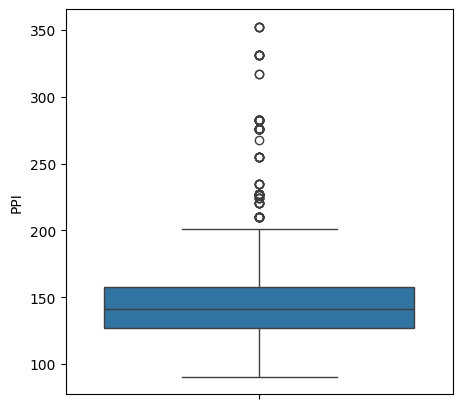

column cpu_performance has outliers percentage = 1.6884113584036837 %
identified outliers [8.43, 8.43, 9.68, 8.43, 7.0, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68, 9.68]


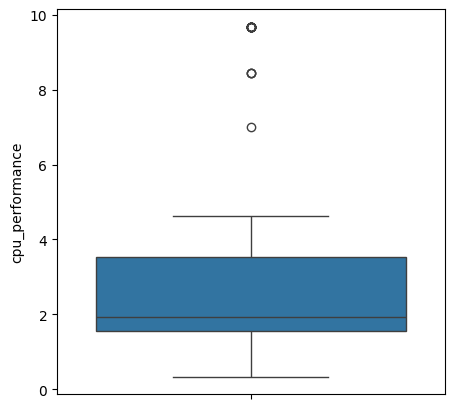

column gpu_performance has outliers percentage = 21.565617805065234 %
identified outliers [7.44, 7.51, 8.31, 12.22, 24.52, 21.02, 32.3, 15.2, 15.2, 12.22, 12.22, 15.2, 17.65, 24.52, 8.8, 24.52, 12.22, 15.2, 32.3, 12.22, 6.43, 12.22, 32.3, 12.22, 12.22, 24.52, 15.2, 24.52, 12.22, 12.22, 12.22, 37.33, 12.22, 24.52, 24.52, 7.67, 24.52, 12.22, 12.22, 17.65, 24.52, 6.15, 24.52, 37.33, 12.22, 6.15, 12.22, 37.33, 17.65, 32.3, 12.22, 21.02, 12.22, 15.2, 12.22, 12.22, 24.52, 15.2, 7.67, 32.3, 17.65, 15.2, 32.3, 6.67, 12.22, 15.2, 12.22, 15.2, 12.22, 24.52, 7.67, 12.22, 17.65, 12.22, 21.02, 12.22, 12.22, 24.52, 7.67, 12.22, 15.2, 15.2, 6.43, 7.67, 12.22, 6.43, 12.22, 32.3, 7.67, 6.43, 12.22, 32.3, 15.2, 32.3, 10.25, 21.02, 12.22, 6.6, 12.22, 6.6, 24.52, 10.25, 17.65, 24.52, 7.67, 6.6, 12.22, 12.22, 6.67, 9.24, 24.52, 37.33, 15.2, 24.52, 32.3, 8.06, 24.52, 24.52, 12.22, 32.3, 6.6, 12.22, 7.67, 32.3, 32.3, 17.65, 12.22, 24.52, 12.22, 6.6, 13.65, 24.52, 10.25, 14.67, 12.22, 32.3, 12.22, 15.2, 12.22

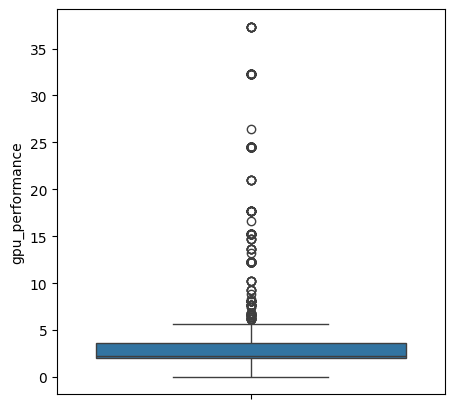

column Weight has outliers percentage = 3.53031465848043 %
identified outliers [4.4, 4.42, 4.7, 3.6, 4.3, 4.14, 4.42, 4.42, 3.78, 4.33, 4.42, 4.42, 4.6, 4.14, 4.5, 3.78, 4.14, 3.8, 4.42, 4.36, 4.2, 4.42, 4.42, 4.3, 4.2, 3.74, 4.36, 4.42, 3.58, 4.36, 4.36, 4.42, 4.42, 3.78, 4.6, 4.0, 3.58, 3.78, 4.6, 4.3, 4.6, 3.52, 3.78, 4.2, 4.3, 4.0]


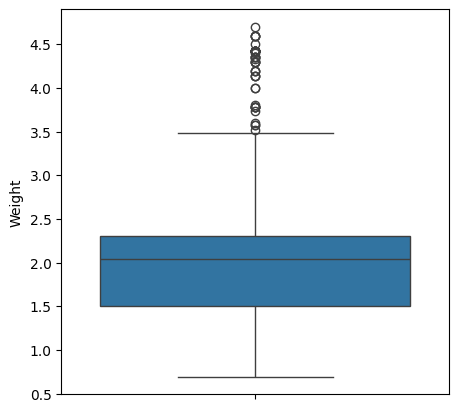

In [ ]:
for k,v in cont_numerical_feat.items():
  q1=v.quantile(0.25)
  q3=v.quantile(0.75)
  iqr=q3-q1
  v_out = v[ (v >= q3+iqr*1.5)  |    (v <= q1-iqr*1.5)]
  perc= np.shape(v_out)[0]*100/np.shape(df)[0]
  print(f'column {k} has outliers percentage = {perc} %')
  print(f'identified outliers {v_out.tolist()}')
  plt.figure(figsize=(5,5))
  sns.boxplot( y= k , data=df)
  plt.show()

from this box plot we concluded that:-


*   in weight values above 4 need to be removed



## **2.4 VISUALIZATION FOR DISCRETE NUMERICAL FEATURES**

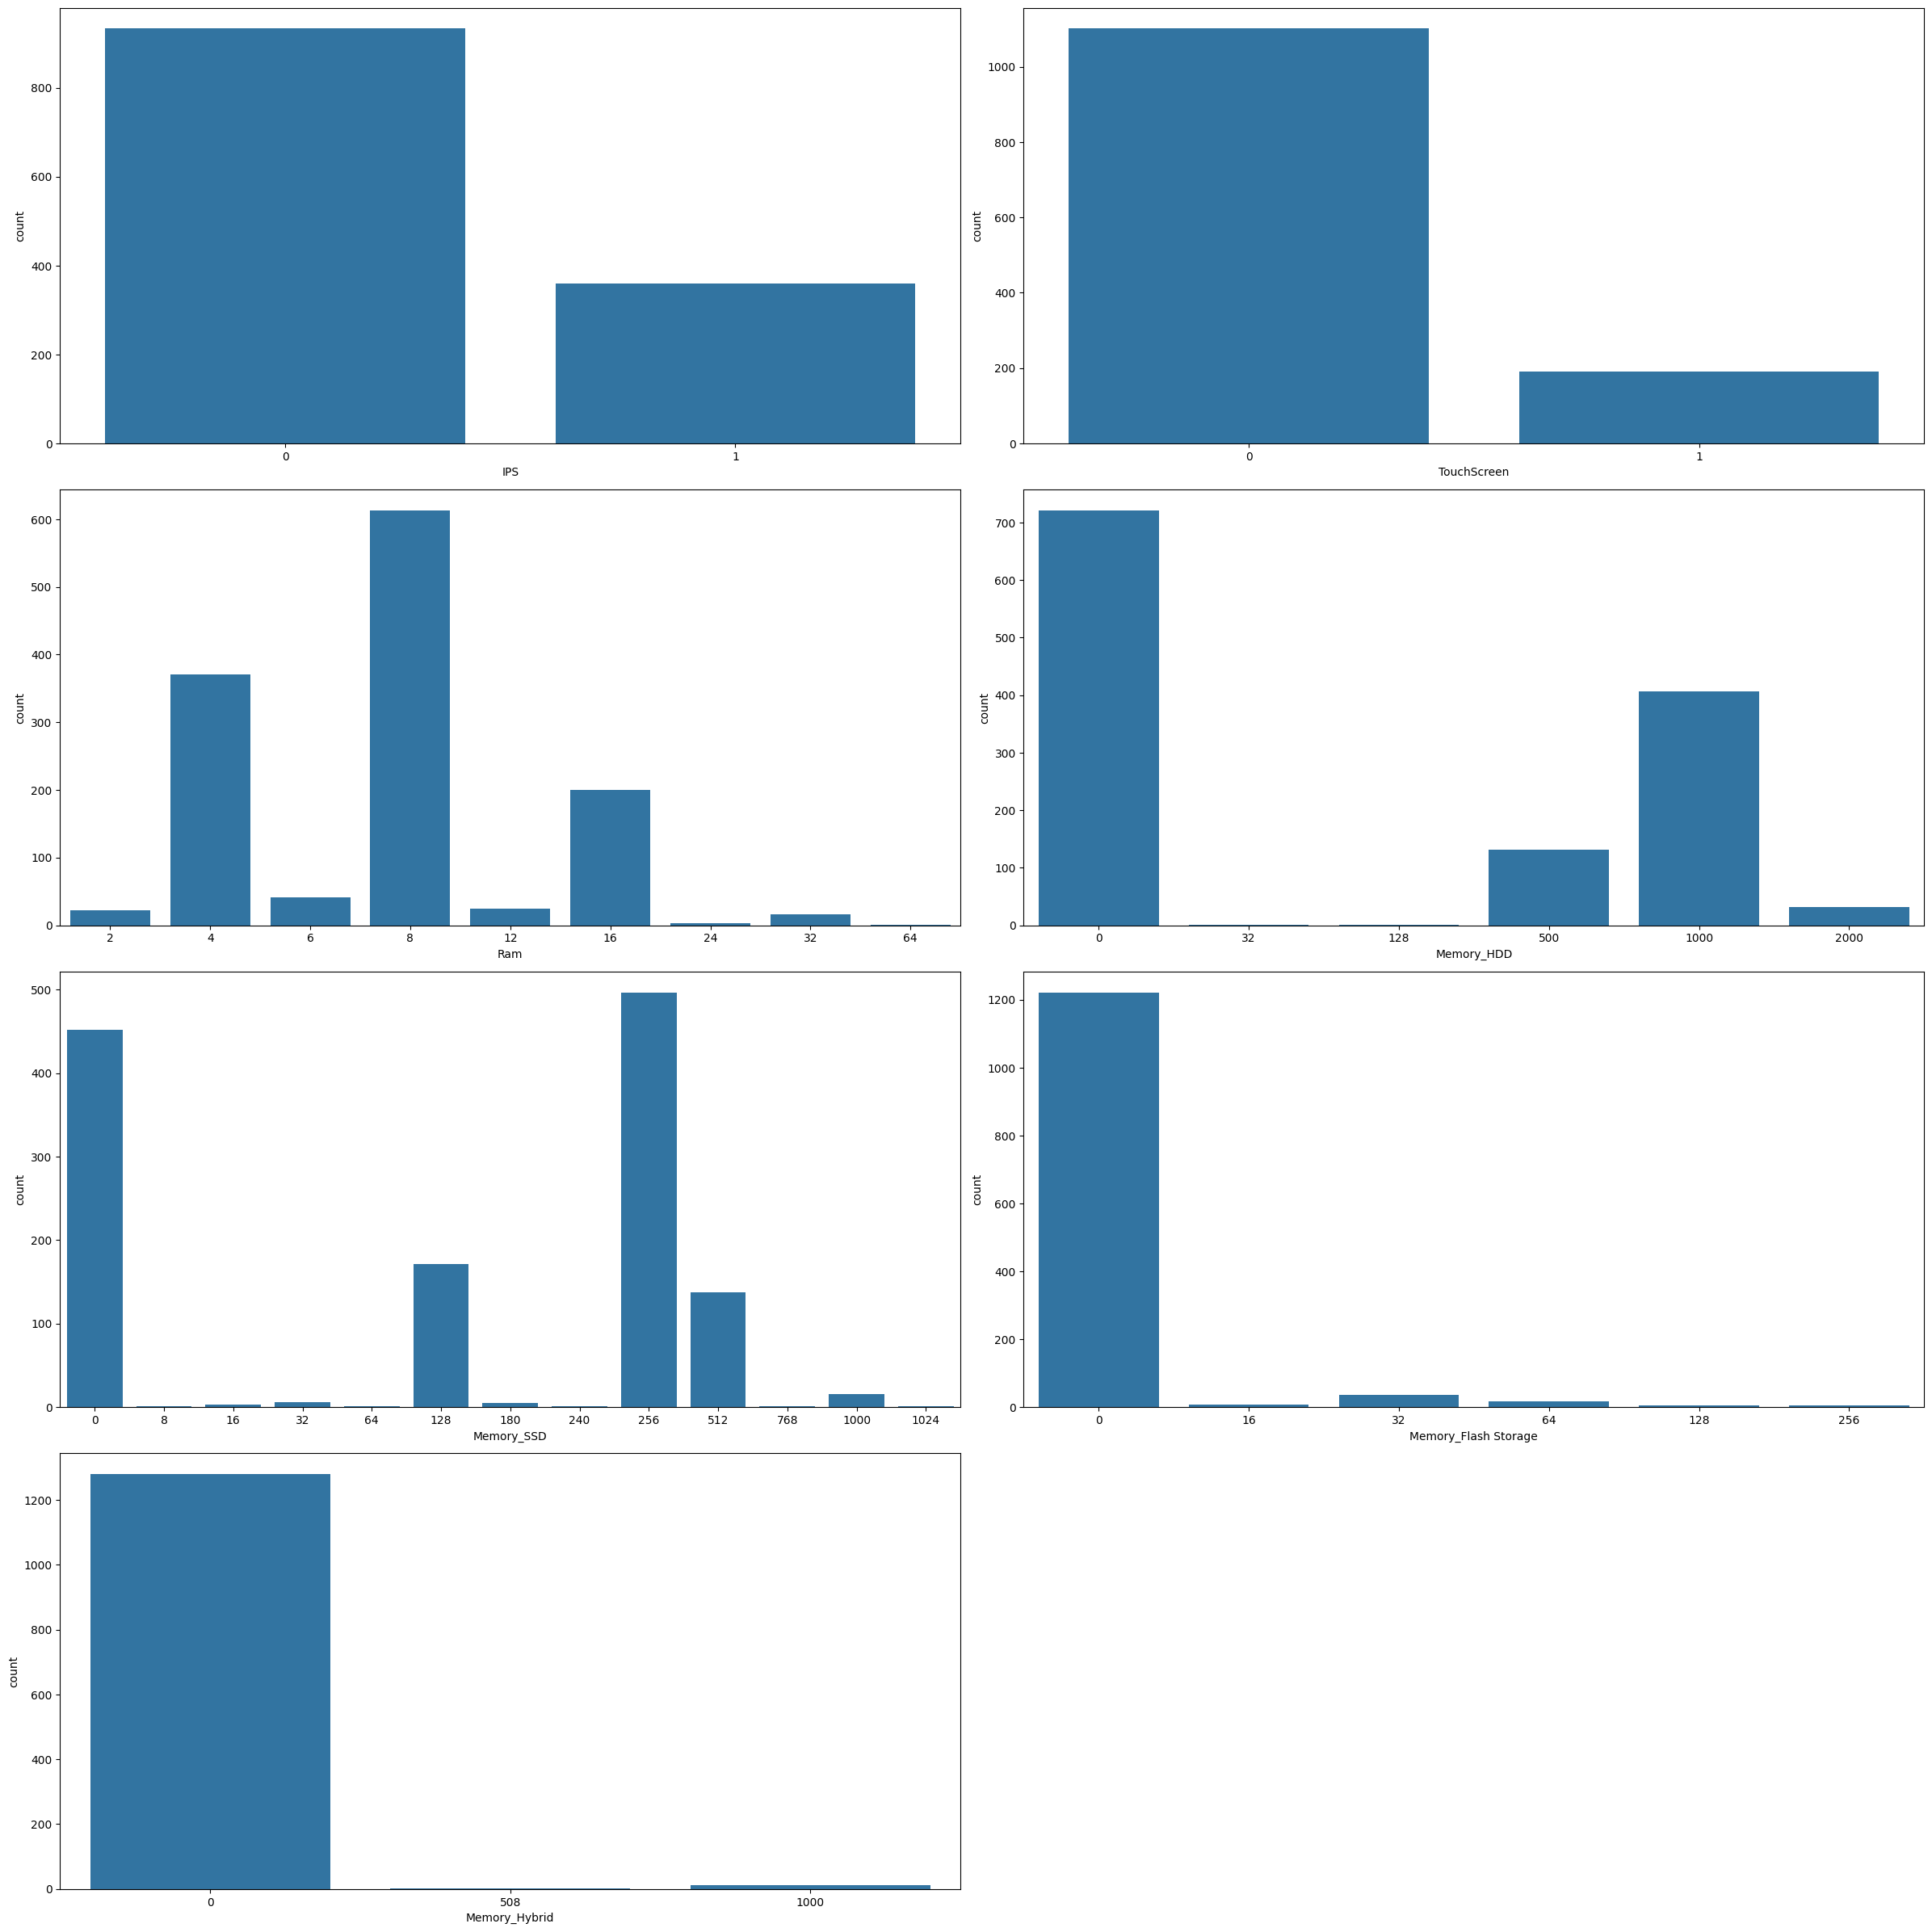

In [ ]:
fig = plt.figure(figsize=(24,24))
for index,col in enumerate(disc_numerical_feat):
    plt.subplot(4,2,index+1)
    sns.countplot(x=col, data=numerical_feat.dropna())
fig.tight_layout(pad=1.0)

## **2.5 VISUALIZATION FOR CATEGORICAL FEATURES**

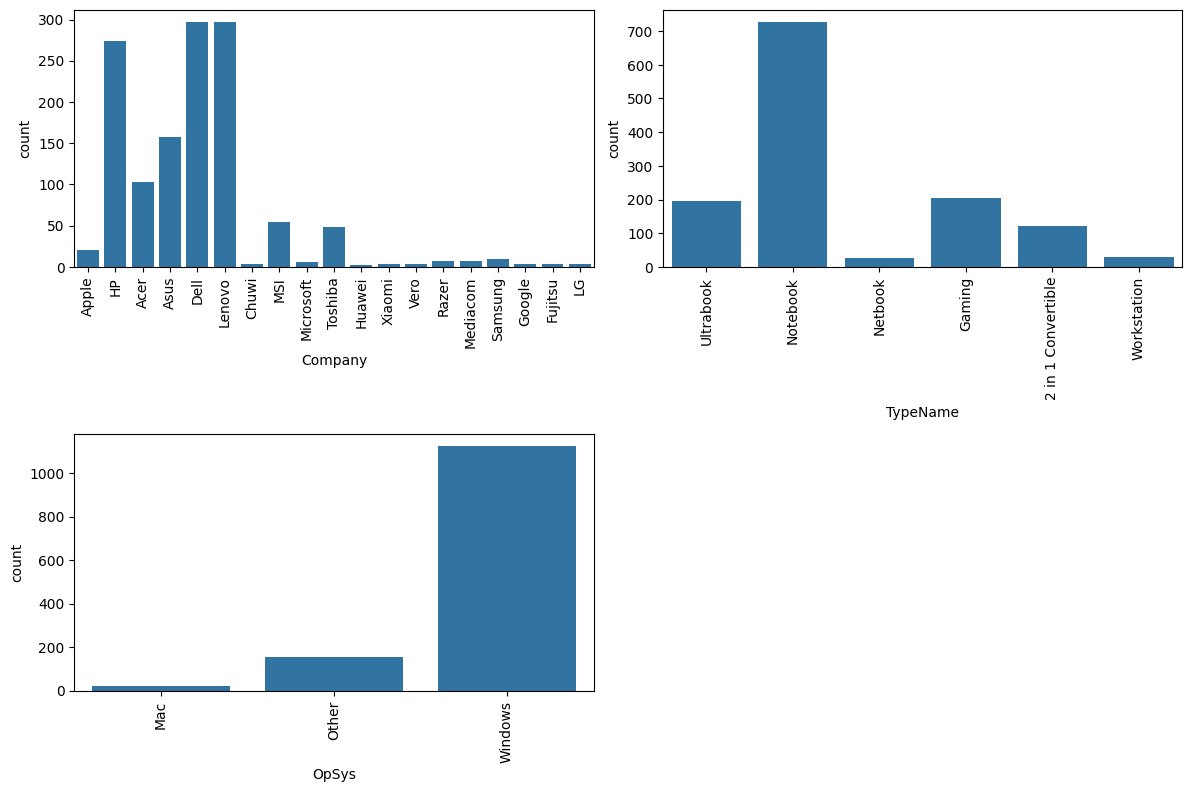

In [ ]:
fig = plt.figure(figsize=(12,8))
for index in range(len(categorical_feat.columns)):
    plt.subplot(2,2,index+1)
    sns.countplot(x=categorical_feat.iloc[:,index], data=categorical_feat.dropna())
    plt.xticks(rotation=90)
fig.tight_layout(pad=1.0)

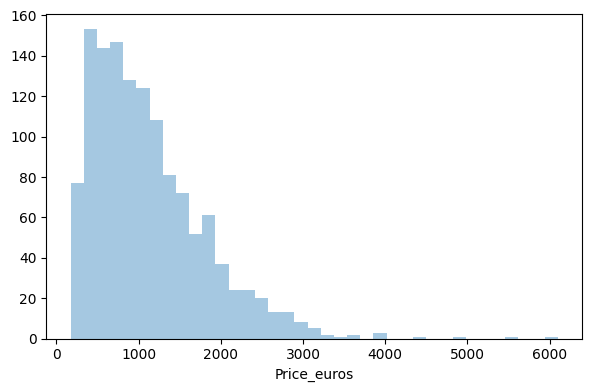

In [ ]:
fig = plt.figure(figsize=(6,4))
sns.distplot(y.dropna(), kde=False)
fig.tight_layout(pad=1.0)

## **2.6 RELATION BETWEEN NUMERICAL FEATURES & TARGET**

<Axes: >

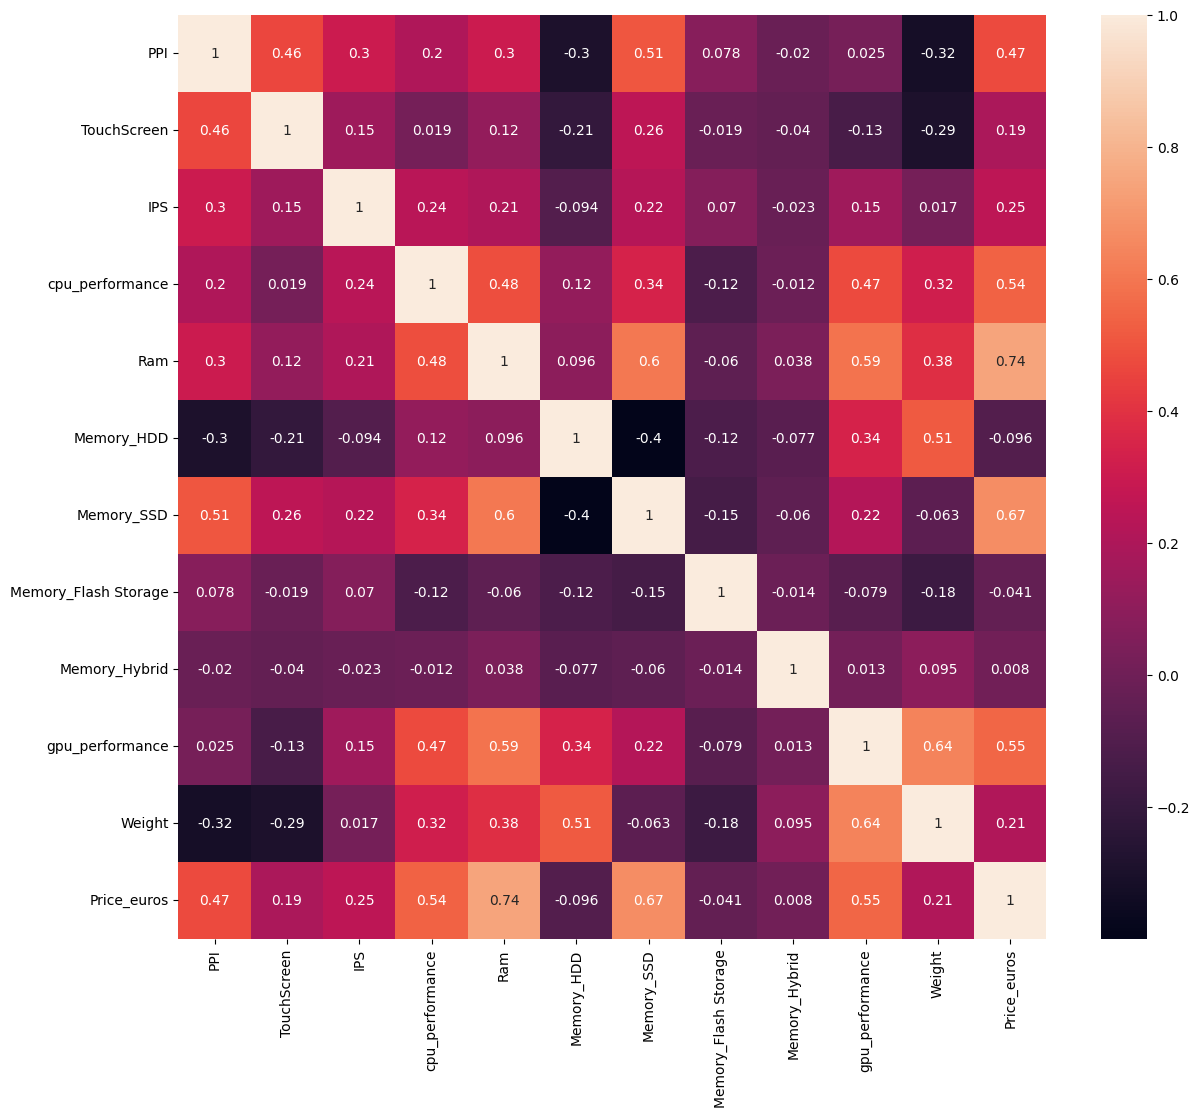

In [ ]:
categ=categorical_feat.columns
num_tar=df.drop(columns=categ , axis=1)
plt.figure(figsize=(14,12))
correlation = num_tar.corr()
sns.heatmap(correlation, annot=True)

from this box plot we concluded that:-



*   Ram has the most correlation with target values




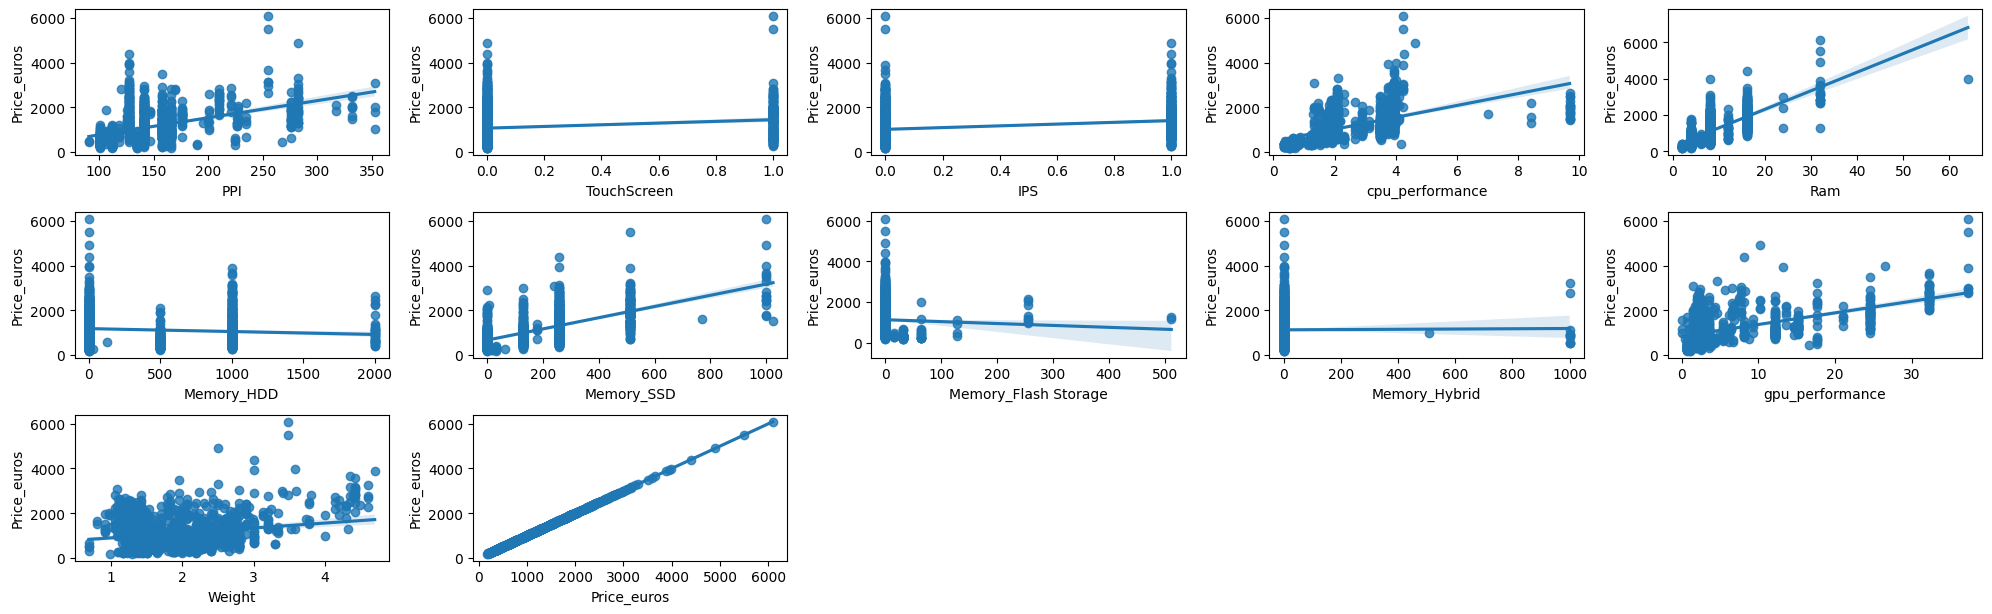

In [ ]:
fig = plt.figure(figsize=(20,20))
for index in range(len(num_tar.columns)):
    plt.subplot(10,5,index+1)
    sns.regplot(x=num_tar.iloc[:,index], y='Price_euros', data=num_tar)
fig.tight_layout(pad=1.0)

# ***3.DATA PREPROCESSING***

## **3.1 TARGET DISTRIBUTION**

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 1 to 1320
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1303 non-null   object 
 1   TypeName              1303 non-null   object 
 2   PPI                   1303 non-null   float64
 3   TouchScreen           1303 non-null   int64  
 4   IPS                   1303 non-null   int64  
 5   cpu_performance       1294 non-null   float64
 6   Ram                   1303 non-null   int64  
 7   Memory_HDD            1303 non-null   int64  
 8   Memory_SSD            1303 non-null   int64  
 9   Memory_Flash Storage  1303 non-null   int64  
 10  Memory_Hybrid         1303 non-null   int64  
 11  gpu_performance       1300 non-null   float64
 12  OpSys                 1303 non-null   object 
 13  Weight                1303 non-null   float64
dtypes: float64(4), int64(7), object(3)
memory usage: 185.0+ KB


In [ ]:
x.head()

,Company,TypeName,PPI,TouchScreen,IPS,cpu_performance,Ram,Memory_HDD,Memory_SSD,Memory_Flash Storage,Memory_Hybrid,gpu_performance,OpSys,Weight
laptop_ID,,,,,,,,,,,,,,
1,Apple,Ultrabook,226.983005,0,1,2.02,8,0,128,0,0,3.56,Mac,1.37
2,Apple,Ultrabook,127.677940,0,0,2.02,8,0,0,128,0,2.03,Mac,1.34
3,HP,Notebook,141.211998,0,0,1.93,8,0,256,0,0,2.24,Other,1.86
4,Apple,Ultrabook,220.534624,0,1,3.95,16,0,512,0,0,7.44,Mac,1.83
5,Apple,Ultrabook,226.983005,0,1,2.02,8,0,256,0,0,4.20,Mac,1.37


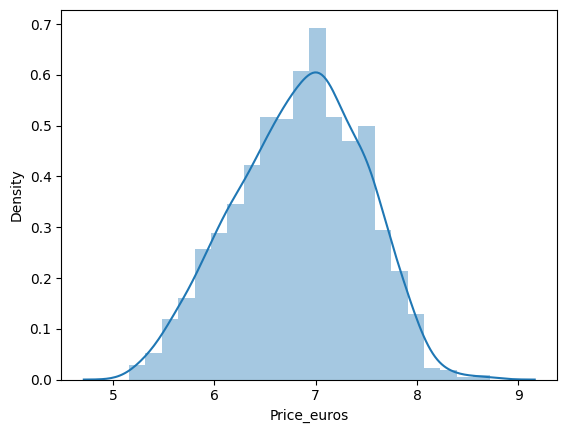

In [ ]:
dist = sns.distplot(np.log(y),norm_hist=False)

In [ ]:
y = np.log(y)


## **3.2 ENCODING CATEGORICAL COLUMNS**

In [ ]:
# categorical_columns=['TypeName','Company','OpSys']
# x=pd.get_dummies(data=x , prefix=categorical_columns , prefix_sep='_' , columns=categorical_columns , drop_first=True , dtype='int8')
# x.head()

## **3.3 TRAIN TEST SPLIT**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.compose import ColumnTransformer


In [ ]:
y = y.loc[x.index]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=74)


# ***4. MODELING***

## **4.1 PREPARE PIPLINES FOR LR , DT , RF & GB MODELS**

In [ ]:
cat_col=['TypeName','Company','OpSys']
num_col=x.drop(columns=cat_col).columns

In [ ]:
num_col

Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')

In [ ]:
num_transf=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scalar',RobustScaler())
])

cat_transf=Pipeline(steps=[
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_transf,num_col),
    ('cat',cat_transf,cat_col)
])

LR_Model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

DT_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',DecisionTreeRegressor(random_state=43))
])

DT_pg=[{
    'regressor__max_depth': [3, 5, 7, 10, None],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}]
DT_gs=GridSearchCV(DT_pipeline,param_grid=DT_pg,cv=5,scoring='r2')

RF_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(random_state=43))
])

RF_pg=[{
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
}]

RF_gs=GridSearchCV(RF_pipeline,param_grid=RF_pg,cv=5,scoring='r2')

GB_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',GradientBoostingRegressor(random_state=43))
])

GB_pg=[{
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__subsample': [0.8, 1.0]
}]

GB_gs=GridSearchCV(GB_pipeline,param_grid=GB_pg,cv=5,scoring='r2')

In [ ]:
print(num_col)
print(cat_col)


Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')
['TypeName', 'Company', 'OpSys']


## **4.2 APPLY HYPERPARAMETER TUNING**

In [ ]:
DT_gs.fit(x_train,y_train)
RF_gs.fit(x_train,y_train)
GB_gs.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scalar',
                                                                                          RobustScaler())]),
                                                                         Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeli...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['TypeName',
                                                                          'Company',
                                                                          'OpSys'])])),
                                       ('regressor',
                                        GradientBoostingRegressor(random_state=43))]),
             param_grid=[{'regressor__learning_rate': [0.05, 0.1, 0.2],
                          'regressor__max_depth': [3, 5, 7],
                          'regressor__min_samples_leaf': [1, 2],
                          'regressor__min_samples_split': [2, 5],
                          'regressor__n_estimators': [100, 200],
                          'regressor__subsample': [0.8, 1.0]}],
             scoring='r2')

In [ ]:
print(DT_gs.best_params_)
print(RF_gs.best_params_)
print(GB_gs.best_params_)

{'regressor__max_depth': 10, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2}
{'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
{'regressor__learning_rate': 0.1, 'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200, 'regressor__subsample': 0.8}


In [ ]:
print(DT_gs.best_estimator_)
print(RF_gs.best_estimator_)
print(GB_gs.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   RobustScaler())]),
                                                  Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['TypeName', 'Company',
                

In [ ]:
DT_Model=DT_gs.best_estimator_
RF_Model=RF_gs.best_estimator_
GB_Model=GB_gs.best_estimator_

## **4.3 MODEL FITTING**

In [ ]:
LR_Model.fit(x_train,y_train)
DT_Model.fit(x_train,y_train)
RF_Model.fit(x_train,y_train)
GB_Model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   RobustScaler())]),
                                                  Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['TypeName', 'Company',
                                                   'OpSys'])])),
                ('regressor',
                 GradientBoostingRegressor(max_depth=5, min_samples_leaf=2,
                                           n_estimators=200, random_state=43,
                                           subsample=0.8))])

## **4.4 MODEL PREDICTION**

In [ ]:
LR_pred=LR_Model.predict(x_test)
DT_pred=DT_Model.predict(x_test)
RF_pred=RF_Model.predict(x_test)
GB_pred=GB_Model.predict(x_test)

In [ ]:
LR_pred_original = np.exp(LR_pred)
DT_pred_original = np.exp(DT_pred)
RF_pred_original = np.exp(RF_pred)
GB_pred_original = np.exp(GB_pred)

y_test_original = np.exp(y_test)

## **4.5 MODEL EVALUATION**

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return pd.DataFrame({
        'Model': [model_name],
        'R2': [r2],
        'MAE': [mae],
        'RMSE': [rmse]
    })


lr_results = evaluate_model('Linear Regression', y_test_original, LR_pred_original)
dt_results = evaluate_model('Decision Tree', y_test_original, DT_pred_original)
rf_results = evaluate_model('Random Forest', y_test_original, RF_pred_original)
gb_results = evaluate_model('Gradient Boosting', y_test_original, GB_pred_original)


final_results = pd.concat([lr_results, dt_results, rf_results, gb_results], axis=0)
final_results = final_results.sort_values(by='R2', ascending=False).reset_index(drop=True)

final_results

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.891992,148.198271,234.030173
1,Random Forest,0.877557,161.152255,249.179371
2,Decision Tree,0.750772,240.979656,355.502961
3,Linear Regression,0.192558,277.496429,639.883034


## **4.6 GB OVERFITTING TEST**

Train R2: 0.9826490428045608
Test R2: 0.8919924582436939


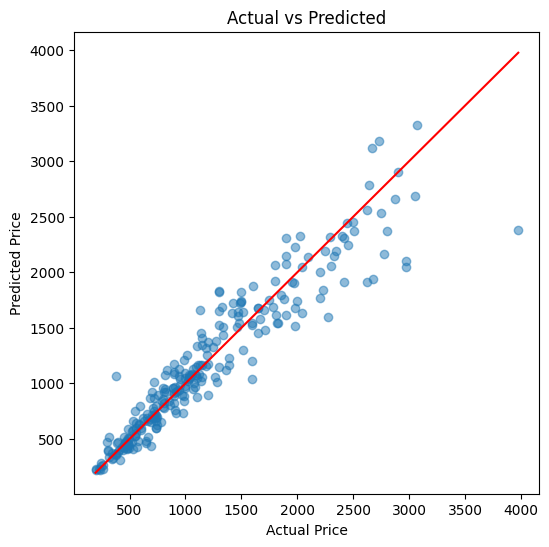

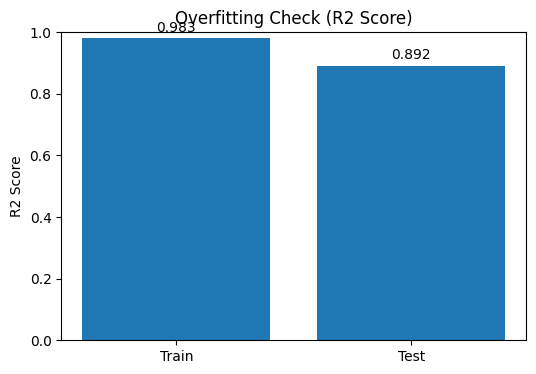

In [ ]:
y_train_orginal=np.exp(y_train)


GB_train_pred = np.exp(GB_Model.predict(x_train))
train_r2 = r2_score(y_train_orginal, GB_train_pred)


test_r2 = r2_score(y_test_original, GB_pred_original)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test_original, GB_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()

## **4.7 RF OVERFITTING TEST**

Train R2: 0.9700610625870733
Test R2: 0.8775568356989177


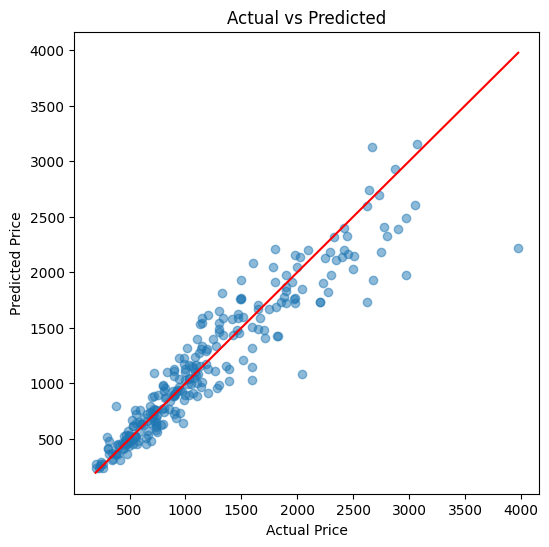

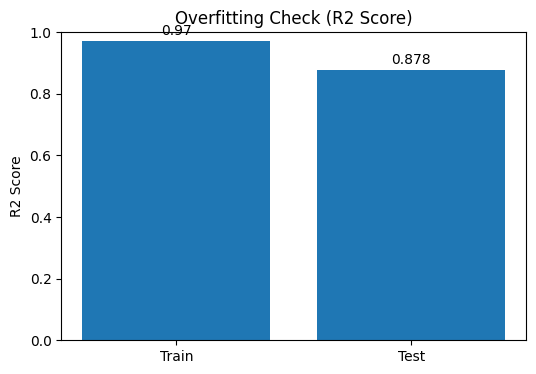

In [ ]:
y_train_orginal=np.exp(y_train)


RF_train_pred = np.exp(RF_Model.predict(x_train))
train_r2 = r2_score(y_train_orginal, RF_train_pred)


test_r2 = r2_score(y_test_original, RF_pred_original)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test_original, RF_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()

## **4.8 DT OVERFITTING TEST**

Train R2: 0.9279888192188058
Test R2: 0.7507720077891413


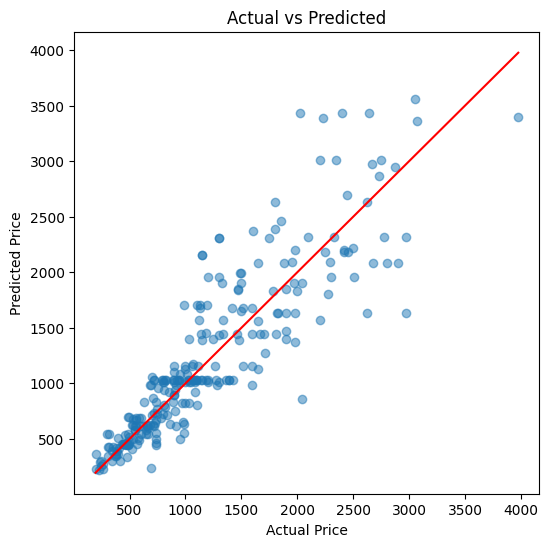

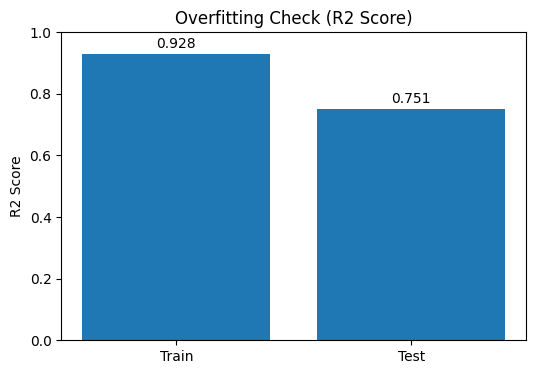

In [ ]:
y_train_orginal=np.exp(y_train)


DT_train_pred = np.exp(DT_Model.predict(x_train))
train_r2 = r2_score(y_train_orginal, DT_train_pred)


test_r2 = r2_score(y_test_original, DT_pred_original)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test_original, DT_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()

## **4.9 LR OVERFITTING TEST**

Train R2: 0.6632263478646536
Test R2: 0.19255757298078569


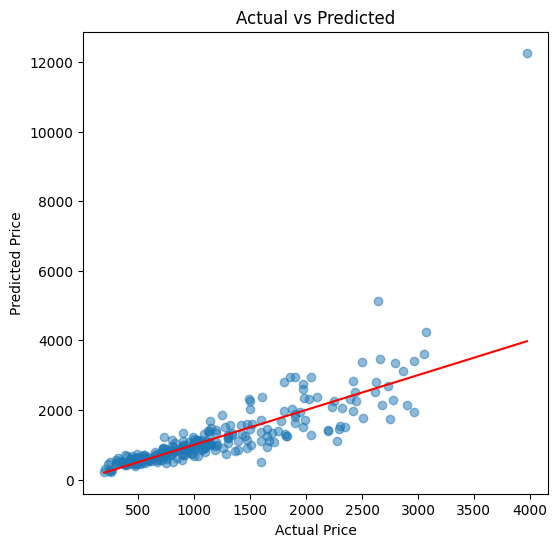

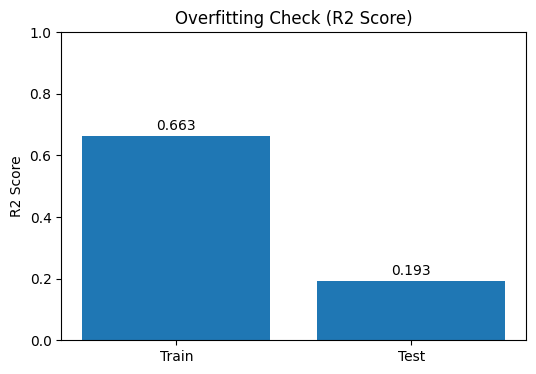

In [ ]:
y_train_orginal=np.exp(y_train)


LR_train_pred = np.exp(LR_Model.predict(x_train))
train_r2 = r2_score(y_train_orginal, LR_train_pred)


test_r2 = r2_score(y_test_original, LR_pred_original)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test_original, LR_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()

# ***5. OVERFITTING SOLUTION***

## **5.1 GRADIANT BOOSTING**

In [ ]:
num_transf=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scalar',StandardScaler())
])

cat_transf=Pipeline(steps=[
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',num_transf,num_col),
    ('cat',cat_transf,cat_col)
])

GB_modle_simplified=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',GradientBoostingRegressor(max_depth=2, min_samples_leaf=1,
                                           n_estimators=200, random_state=43,
                                           subsample=0.8))
])


In [ ]:
GB_modle_simplified.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['PPI', 'TouchScreen', 'IPS', 'cpu_performance', 'Ram', 'Memory_HDD',
       'Memory_SSD', 'Memory_Flash Storage', 'Memory_Hybrid',
       'gpu_performance', 'Weight'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['TypeName', 'Company',
                                                   'OpSys'])])),
                ('regressor',
                 GradientBoostingRegressor(max_depth=2, n_estimators=200,
                                           random_state=43, subsample=0.8))])

In [ ]:
GB_simplified_pred=GB_modle_simplified.predict(x_test)

In [ ]:
GB_simplified_pred_original = np.exp(GB_simplified_pred)

In [ ]:
lr_results = evaluate_model('Linear Regression', y_test_original, LR_pred_original)
dt_results = evaluate_model('Decision Tree', y_test_original, DT_pred_original)
rf_results = evaluate_model('Random Forest', y_test_original, RF_pred_original)
gb_results = evaluate_model('Gradient Boosting', y_test_original, GB_pred_original)
gb_simp_results = evaluate_model('Gradient Boosting simplified', y_test_original, GB_simplified_pred_original)

final_results = pd.concat([lr_results, dt_results, rf_results, gb_results,gb_simp_results], axis=0)
final_results = final_results.sort_values(by='R2', ascending=False).reset_index(drop=True)

final_results

,Model,R2,MAE,RMSE
0,Gradient Boosting,0.891992,148.198271,234.030173
1,Gradient Boosting simplified,0.886305,164.128646,240.113083
2,Random Forest,0.877557,161.152255,249.179371
3,Decision Tree,0.750772,240.979656,355.502961
4,Linear Regression,0.192558,277.496429,639.883034


Train R2: 0.8871244793421595
Test R2: 0.886304827874437


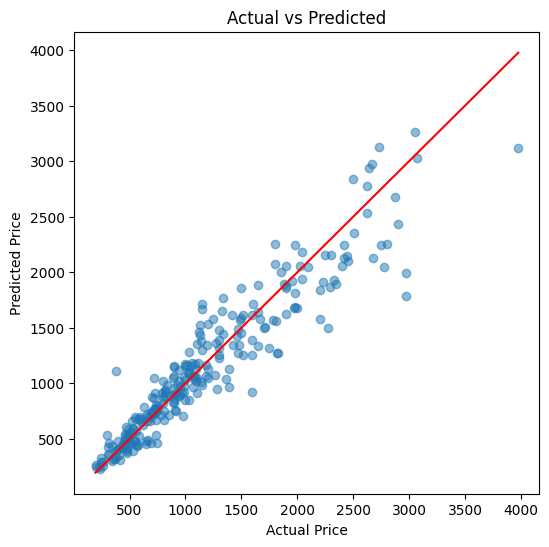

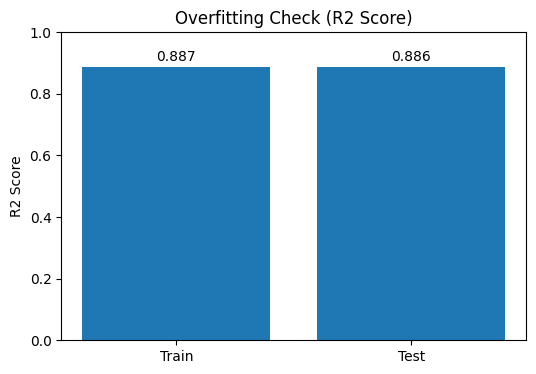

In [ ]:
y_train_orginal=np.exp(y_train)


GB_train_pred = np.exp(GB_modle_simplified.predict(x_train))
train_r2 = r2_score(y_train_orginal, GB_train_pred)


test_r2 = r2_score(y_test_original, GB_simplified_pred_original)


print("Train R2:", train_r2)
print("Test R2:", test_r2)



plt.figure(figsize=(6,6))

plt.scatter(y_test_original, GB_simplified_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()],
         color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()



labels = ['Train', 'Test']
scores = [train_r2, test_r2]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)
plt.title('Overfitting Check (R2 Score)')
plt.ylabel('R2 Score')
plt.ylim(0,1)

for i, v in enumerate(scores):
    plt.text(i, v + 0.02, round(v, 3), ha='center')

plt.show()